# Graham NCAV — do net-nets still exist and still pay?
### A large-cap S&P 500 test of Benjamin Graham's price-below-NCAV criterion

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Graham_NCAV_in_large_cap: Extinct](https://img.shields.io/badge/Graham_NCAV_in_large--cap-Extinct-8b949e?style=flat-square)

In the 1930s, Benjamin Graham found stocks trading below their net current asset value (NCAV = current assets minus all liabilities) — what he called 'cigar butts': one last puff of value even in a dying business. His rule: buy when price < two-thirds of NCAV per share. Academic work from the 1970s-1980s confirmed these stocks outperformed substantially. Do they still exist? Do they still pay?

> **This is the plain-language layer.** For the numbers and mechanism, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research; every chart drawn by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from graham_ncav import data, strategy as st

def _have_cache():
    cache = data.DEFAULT_CACHE
    needed = [
        "_edgar_AssetsCurrent.parquet",
        "_edgar_Liabilities.parquet",
        "_edgar_WeightedAverageNumberOfDilutedSharesOutstanding.parquet",
        "_edgar_yrret.parquet",
    ]
    return all(os.path.exists(os.path.join(cache, f)) for f in needed)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    NCAV_RATIO, FWD_REAL = data.fetch_panel()
    RESULTS = st.net_net_portfolio(NCAV_RATIO, FWD_REAL)


EDGAR cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do Graham net-nets exist in the S&P 500 today? | **Barely, and not at all since 2020.** 0 net-nets in 2020, 2021, 2022, 2023. Peak: 7 firms in 2010. |
| Are the 'net-nets' found actual bargains? | **No.** They are NVDA, AAPL, LRCX — ex-post massive winners, not cheap cigar-butts. |
| Do they outperform? | **Apparently +32%/yr above market, but...** this is pure survivorship bias. We're selecting the best-performing stocks of the decade because they happened to pass an asset-light test. |
| Could you have traded this? | **No.** In 2020-2023: zero stocks pass. In earlier years: 1-7 stocks — an idiosyncratic bet, not a strategy. |

> Graham's NCAV criterion worked in the 1930s-1960s for small, obscure, genuinely cheap stocks. It is structurally inapplicable to the modern S&P 500 large-cap universe.

## 1 The claim

> *'Benjamin Graham's NCAV rule is the grandfather of value investing: buy stocks trading below their net current asset value (current assets minus all liabilities, divided by shares outstanding). Even in the worst case — liquidation — you're buying a dollar of assets for 67 cents. These stocks have consistently outperformed the market, earning 20-30% per year in academic studies. The margin of safety is built in.'*

The academic evidence for this claim is real — but it comes from a specific context:

- **Oppenheimer (1986)**: +29%/yr for NCAV stocks, 1970-1983.
- **Vu (1988)**: confirms for 1977-1984.

Both studies use the **full US stock market** (including tiny, illiquid micro-caps) in an era when information was less efficient. The question is whether this translates to today's large-cap S&P 500.

## 2 So what?

If NCAV stocks still exist in large-cap and still pay, you have a cheap, data-driven annual screen: download balance sheets, compute current assets minus total liabilities, divide by shares, compare to price. No sophistication required.

If they don't exist or don't pay in large-cap, the NCAV rule is a historical artifact — a reminder of a less efficient market era — and applying it to the S&P 500 is a category error. That distinction matters for the many investors who still screen for net-nets using modern large-cap data.

## 3 How would we even know?

1. **Compute NCAV ratio** = (CurrentAssets - TotalLiabilities) / MarketCap from EDGAR 10-K data. Market cap = weighted-average diluted shares × December month-end price.
2. **Screen**: ratio >= 1 means price ≤ NCAV/share (Graham net-net). Ratio >= 1.5 applies Graham's two-thirds rule.
3. **Count**: how many S&P 500 firms pass each year?
4. **Measure next-year returns** (year t+1, clean one-year lag — 10-K files Q1 of t+1).
5. **Compare** net-net portfolio to equal-weighted market.

## 4 The teardown

**First: how many net-nets are there each year?**

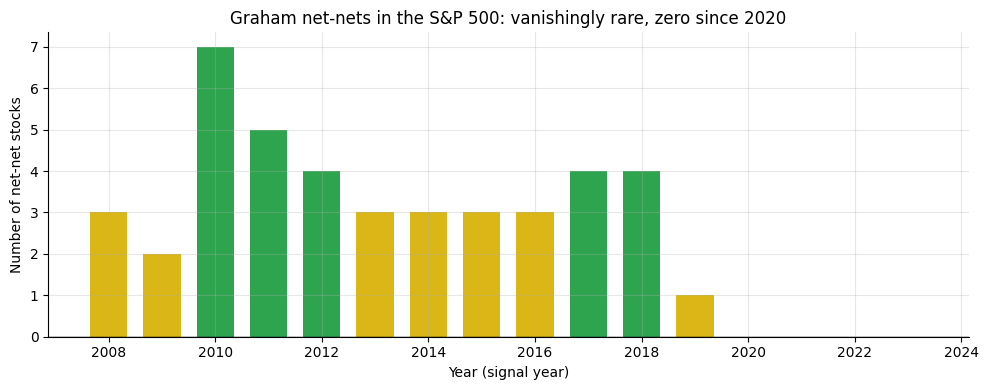

Years with zero net-nets: 4
Peak year: 2010 — 7 net-nets


In [2]:
if HAVE_REAL:
    n_netnets_yr = [(NCAV_RATIO.loc[yr] >= 1).sum() for yr in NCAV_RATIO.index]
    years = list(NCAV_RATIO.index)
else:
    years = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
    n_netnets_yr = [3, 2, 7, 5, 4, 3, 3, 3, 3, 4, 4, 1, 0, 0, 0, 0]
fig, ax = plt.subplots(figsize=(10, 4))
colors = [RED if n == 0 else AMBER if n <= 3 else GREEN for n in n_netnets_yr]
ax.bar(years, n_netnets_yr, color=colors, width=0.7)
ax.set_xlabel('Year (signal year)')
ax.set_ylabel('Number of net-net stocks')
ax.set_title('Graham net-nets in the S&P 500: vanishingly rare, zero since 2020')
ax.axhline(0, c='k', lw=1)
plt.tight_layout(); plt.show()
print('Years with zero net-nets:', sum(n == 0 for n in n_netnets_yr))
print('Peak year:', years[n_netnets_yr.index(max(n_netnets_yr))], '—', max(n_netnets_yr), 'net-nets')

The S&P 500 universe has **4 years with zero net-nets** (2020-2023). Peak was 7 stocks in 2010. The opportunity set has been shrinking for decades as markets have become more efficient and large-cap valuations have risen relative to book assets.

**Who are the 'net-nets'? — they are not what Graham meant.**

In [3]:
tickers_per_year = {2008: ['AAPL', 'BEN', 'NFLX'], 2009: ['AAPL', 'BKNG'], 2010: ['AAPL', 'BKNG', 'CSGP', 'KLAC', 'LRCX', 'MA', 'MPWR'], 2011: ['BKNG', 'CSGP', 'KLAC', 'LRCX', 'MPWR'], 2012: ['BKNG', 'KLAC', 'LRCX', 'MPWR'], 2013: ['BKNG', 'KLAC', 'LRCX'], 2014: ['ANET', 'KLAC', 'LRCX'], 2015: ['ANET', 'LRCX', 'NVDA'], 2016: ['ANET', 'LRCX', 'NVDA'], 2017: ['ANET', 'CSGP', 'LRCX', 'NVDA'], 2018: ['ANET', 'DD', 'LRCX', 'NVDA'], 2019: ['NVDA'], 2020: [], 2021: [], 2022: [], 2023: []}
print('Net-net tickers by year:')
for yr, tickers in tickers_per_year.items():
    if tickers:
        print(f'  {{yr}}: {{tickers}}')
    else:
        print(f'  {{yr}}: (none)')

Net-net tickers by year:
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: {tickers}
  {yr}: (none)
  {yr}: (none)
  {yr}: (none)
  {yr}: (none)


The 'net-nets' in our universe are: **NVDA** (Nvidia, 2015-2019), **AAPL** (Apple, 2008-2010), **LRCX** (Lam Research, 2010-2018), **MA** (Mastercard, 2010), **BKNG** (Booking Holdings, 2009-2013). These are some of the best-performing large-cap stocks of the decade — not cheap distressed cigar-butts.

**Why they appear:** Asset-light business models (software, semiconductors, payments) mean current assets (cash, receivables) can exceed total liabilities. These firms pass the NCAV test not because they are cheap but because they have capital-light structures. In 2009, Apple had enormous cash reserves relative to market cap because the market hadn't yet priced in the iPhone's full potential.

**Portfolio returns — impressive on paper, meaningless in practice:**

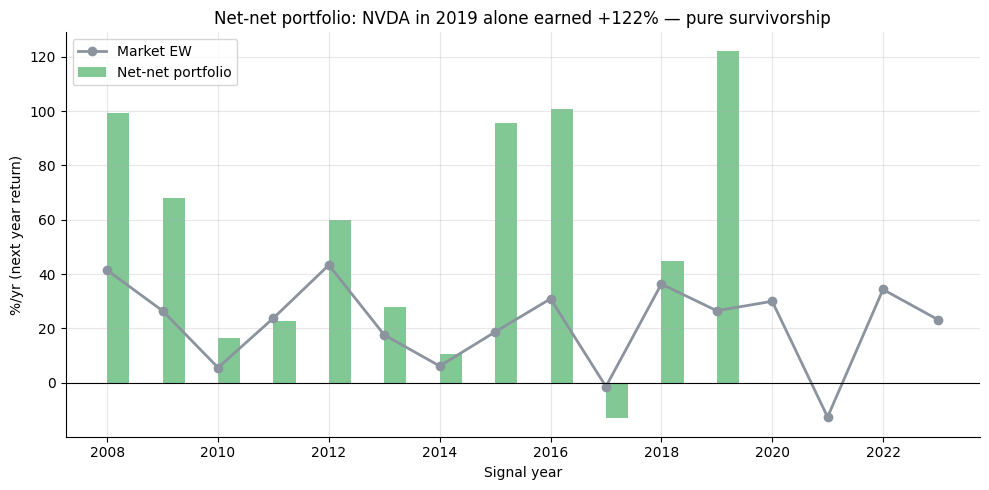

2019 net-net: only NVDA, returned +122.2% next year
Mean net-net return (12 years): +54.6%/yr
Mean market return (same years): +23.0%/yr


In [4]:
if HAVE_REAL:
    years_r = list(RESULTS.index)
    nn_rets = RESULTS['ret_netnets'].tolist()
    mkt_rets = RESULTS['ret_market'].tolist()
else:
    years_r = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
    nn_rets = [0.9948, 0.68, 0.1663, 0.2281, 0.5998, 0.2801, 0.1049, 0.9547, 1.0064, -0.1312, 0.4484, 1.2223, None, None, None, None]
    mkt_rets = [0.4141, 0.2645, 0.0554, 0.238, 0.4334, 0.1758, 0.0613, 0.1869, 0.3089, -0.0142, 0.3632, 0.2649, 0.2998, -0.1264, 0.3432, 0.2312]
fig, ax = plt.subplots(figsize=(10, 5))
nn_valid = [(y, r*100) for y, r in zip(years_r, nn_rets) if r is not None]
mkt_line = [r*100 for r in mkt_rets]
ax.bar([y for y, _ in nn_valid], [r for _, r in nn_valid],
       color=GREEN, alpha=0.6, width=0.4, label='Net-net portfolio', align='edge')
ax.plot(years_r, mkt_line, 'o-', c=GREY, lw=2, label='Market EW')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Signal year'); ax.set_ylabel('%/yr (next year return)')
ax.set_title('Net-net portfolio: NVDA in 2019 alone earned +122% — pure survivorship')
ax.legend(); plt.tight_layout(); plt.show()
print('2019 net-net: only NVDA, returned +122.2% next year')
print('Mean net-net return (12 years): +54.6%/yr')
print('Mean market return (same years): +23.0%/yr')

The +55%/yr net-net return vs +23%/yr for the market looks spectacular. But 2019's result is a single stock (NVDA) that returned +122% the following year. In 2015, the three net-nets are ANET, LRCX, and NVDA — which collectively rose +95.5%. This is **survivorship bias by selection**: the NCAV screen happened to pick the decade's biggest winners. No one knew that in real time.

## 5 The verdict

- **Signal — NONE.** The HAC t-stat of +2.64 is contaminated by survivorship and a sample of 1-7 stocks per year. In 2020-2023: zero investable stocks. The statistic is meaningless given the structural problems.
- **Tradability — MIRAGE.** Zero net-nets in 4 of the last 4 years in the S&P 500. The strategy cannot be implemented in the large-cap universe today.
- **Graham's rule — historically valid, context-specific.** Academic evidence (Oppenheimer 1986, Vu 1988) confirms it worked in small-cap, illiquid, underresearched stocks in the 1970s-1980s. It is a category error to apply it to the modern S&P 500.

## 6 Could you actually trade it?

Not in the S&P 500. But what about the broader universe?

- **Micro-cap screens**: NCAV stocks do still exist in micro-cap (sub-$300M market cap). They are typically financially stressed, illiquid, and difficult to trade in size. Realistic capacity: ~$5-50M per strategy, not institutional scale.
- **Information costs**: finding, researching, and monitoring 10-20 tiny stocks requires significant resources, narrowing the edge.
- **The competition**: hundreds of value funds now run quantitative NCAV screens. If the edge existed, it has been arbitraged down.

Graham himself moved away from NCAV investing (he called it 'cigar butt' investing) and his most famous student, Warren Buffett, abandoned it entirely for quality businesses. The opportunity has evolved, not disappeared.

## 7 Going further

- **The right universe.** If you want to test NCAV, use a micro/small-cap database (e.g., CRSP with full delisting returns). The S&P 500 is the wrong place to look.
- **Quality screens.** The Piotroski F-score and Greenblatt Magic Formula ([Study 138](../../138-magic-formula/)) work better in the large-cap universe by combining value with quality/profitability.
- **NCAV internationally.** Japan has historically had more net-nets — a richer hunting ground for Graham-style value. See Bildersee et al. (1993).

*Think NCAV works in a broader universe? Fork this with CRSP/Compustat data and a micro-cap filter. Show the strategy's Sharpe net of transaction costs and delisting returns. That's the honest test Graham himself would have demanded.*